In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rsnngo/37ft-thang3737/val_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/train_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/full_dataset_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_minmax_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/class_weights_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/feature_columns_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/audit_report_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_standard_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/dist_label8_precap_vs_postcap_p3.2.png
/kaggle/input/datasets/rsnng

In [2]:
import os
import json
import pandas as pd

OUTPUT_DIR = "/kaggle/working/"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
metadata_path = f"{OUTPUT_DIR}/metadata.json"

def create_metadata_from_parquet(train_path):
    df = pd.read_parquet(train_path)
    all_columns = df.columns.tolist()
    target_col = 'label'
    if target_col not in all_columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    feature_cols = [col for col in all_columns if col != target_col]
    num_features = len(feature_cols)
    unique_labels = sorted(df[target_col].astype(str).unique())
    num_classes = len(unique_labels)
    label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
    id_to_label = {str(idx): label for idx, label in enumerate(unique_labels)}
    metadata = {
        "feature_cols": feature_cols,
        "target_col": target_col,
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "num_classes": num_classes,
        "num_features": num_features
    }
    return metadata

if not os.path.exists(metadata_path):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    metadata = create_metadata_from_parquet(TRAIN_PATH)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")
else:
    print("Metadata already exists.")

Metadata saved to /kaggle/working//metadata.json


In [3]:
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

def compute_sqrt_balanced_weights(y):
    """
    Tính trọng số balanced (tỉ lệ nghịch với tần suất) và lấy căn bậc 2
    để giảm chênh lệch giữa các lớp.
    """
    weights = compute_sample_weight('balanced', y)
    return np.sqrt(weights)

In [4]:
# Cell 3: Tối ưu siêu tham số XGBoost bằng Optuna (dựa trên macro F1, có RESUME)
!pip install optuna-integration[xgboost] -q

import json, pandas as pd, numpy as np, xgboost as xgb, time, os
import optuna
from optuna.storages import RDBStorage
from sklearn.metrics import f1_score

OUTPUT_DIR = "/kaggle/working/"
DB_PATH = f"{OUTPUT_DIR}/optuna_study_f1.db"          # đổi tên để dùng mới
STUDY_NAME = "xgboost_ciciot_optimization_f1"

# 1. Load metadata và dữ liệu
with open(f"{OUTPUT_DIR}/metadata.json") as f:
    metadata = json.load(f)
feature_cols = metadata['feature_cols']
target_col = metadata['target_col']
label_to_id = metadata['label_to_id']
num_classes = metadata['num_classes']

TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[target_col].astype(str).map(label_to_id).values
X_val = df_val[feature_cols].values.astype(np.float32)
y_val = df_val[target_col].astype(str).map(label_to_id).values

# Tính trọng số mẫu với căn bậc 2
sample_weights = compute_sqrt_balanced_weights(y_train)

# Tạo DMatrix có trọng số cho train, validation giữ nguyên không weight
dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dval = xgb.DMatrix(X_val, label=y_val)

# 2. Hàm objective (dùng callback tính F1, pruning)
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',   # vẫn giữ logloss để early stopping
        'random_state': 42,
        'verbosity': 0,
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    # Callback tùy chỉnh: tính F1 mỗi vòng và báo cáo cho Optuna
    class F1Callback(xgb.callback.TrainingCallback):
        def __init__(self, trial, dval, y_true):
            self.trial = trial
            self.dval = dval
            self.y_true = y_true
            self.best_f1 = -1.0
        
        def after_iteration(self, model, epoch, evals_log):
            y_pred_proba = model.predict(self.dval)
            y_pred = np.argmax(y_pred_proba.reshape(-1, num_classes), axis=1)
            f1 = f1_score(self.y_true, y_pred, average='macro')
            self.trial.report(f1, step=epoch)
            if f1 > self.best_f1:
                self.best_f1 = f1
            if self.trial.should_prune():
                raise optuna.TrialPruned()
            return False   # tiếp tục huấn luyện
    
    f1_cb = F1Callback(trial, dval, y_val)
    
    evals_result = {}
    model = xgb.train(
        params, dtrain,
        num_boost_round=500,
        evals=[(dval, 'validation')],
        evals_result=evals_result,
        early_stopping_rounds=10,
        verbose_eval=False,
        callbacks=[f1_cb]
    )
    
    return f1_cb.best_f1

# 3. Tạo Storage và Study (direction = maximize)
storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    study = optuna.load_study(study_name=STUDY_NAME, storage=storage)
    print(f"✅ Đã tải study '{STUDY_NAME}' từ database. Số trial đã chạy: {len(study.trials)}")
    if study.direction != optuna.study.StudyDirection.MAXIMIZE:
        print("⚠️ Study hiện tại không có direction MAXIMIZE. Tạo mới (xoá dữ liệu cũ).")
        optuna.delete_study(study_name=STUDY_NAME, storage=storage)
        study = optuna.create_study(
            study_name=STUDY_NAME,
            storage=storage,
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=42),
            pruner=optuna.pruners.MedianPruner()
        )
except KeyError:
    study = optuna.create_study(
        study_name=STUDY_NAME,
        storage=storage,
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )
    print(f"✅ Tạo mới study '{STUDY_NAME}' (direction = maximize).")

print("Bắt đầu tối ưu với Optuna...")
study.optimize(objective, n_trials=100, timeout=3600*11, show_progress_bar=True)

# Lưu best params
best_params = study.best_params
with open(f"{OUTPUT_DIR}/best_params.json", 'w') as f:
    json.dump(best_params, f, indent=4)

print(f"\n=== Đã hoàn thành (hoặc đạt timeout) ===")
print(f"Tổng số trials đã chạy: {len(study.trials)}")
print(f"Best macro F1: {study.best_value:.6f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 1.1 MB/s eta 0:00:00


[I 2026-07-17 07:38:20,616] A new study created in RDB with name: xgboost_ciciot_optimization_f1


✅ Tạo mới study 'xgboost_ciciot_optimization_f1' (direction = maximize).
Bắt đầu tối ưu với Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-17 07:59:54,204] Trial 0 finished with value: 0.7277587142193429 and parameters: {'max_depth': 7, 'learning_rate': 0.4463590152176813, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 2.275053705838343e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.7277587142193429.
[I 2026-07-17 08:24:41,143] Trial 1 finished with value: 0.73177050223646 and parameters: {'max_depth': 8, 'learning_rate': 0.2552951604697377, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 7.032853236588588e-07, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 1 with value: 0.73177050223646.
[I 2026-07-17 08:45:20,958] Trial 2 finished with value: 0.7307447804879683 and parameters: {'max_depth': 6, 'learning_rate': 0.16738881542579662, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792

In [5]:
# Cell 3.5: Vẽ biểu đồ Optuna tùy chỉnh (hiển thị F1) + Param Importance
import optuna
from optuna.storages import RDBStorage
import matplotlib.pyplot as plt
import numpy as np
import optuna.visualization.matplotlib as vis

OUTPUT_DIR = "/kaggle/working/"
DB_PATH = f"{OUTPUT_DIR}/optuna_study_f1.db"
STUDY_NAME = "xgboost_ciciot_optimization_f1"

storage = RDBStorage(url=f'sqlite:///{DB_PATH}')
study = optuna.load_study(study_name=STUDY_NAME, storage=storage)

print(f"Tổng số trials đã chạy: {len(study.trials)}")

# ===== Optimization History (custom) =====
trials = study.trials
completed = [t for t in trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in trials if t.state == optuna.trial.TrialState.PRUNED]

fig1, ax1 = plt.subplots(figsize=(10, 6))

if completed:
    x_comp = [t.number for t in completed]
    y_comp = [t.value for t in completed]
    ax1.scatter(x_comp, y_comp, color='blue', label='Completed', s=30)

if pruned:
    x_prun = []
    y_prun = []
    for t in pruned:
        if t.intermediate_values:
            last_step = max(t.intermediate_values.keys())
            y_prun.append(t.intermediate_values[last_step])
            x_prun.append(t.number)
    if x_prun:
        ax1.scatter(x_prun, y_prun, color='gray', label='Pruned', s=30, alpha=0.6)

# Đường best F1 (max)
best_vals = []
current_best = -float('inf')
for t in sorted(trials, key=lambda x: x.number):
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None:
        if t.value > current_best:
            current_best = t.value
    best_vals.append(current_best)

ax1.plot(range(len(best_vals)), best_vals, color='green', linestyle='-', linewidth=2, label='Best F1')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Objective Value (Macro F1)')
ax1.set_title('Optimization History (Completed and Pruned)')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/optuna_optimization_history_custom.png", dpi=150)
plt.close(fig1)

# ===== Param Importance =====
fig2 = vis.plot_param_importances(study)
fig2.figure.savefig(f"{OUTPUT_DIR}/optuna_param_importances.png", dpi=150, bbox_inches='tight')
plt.close(fig2.figure)

# ===== Parallel Coordinate =====
fig3 = vis.plot_parallel_coordinate(
    study, 
    params=['max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight']
)
fig3.figure.savefig(f"{OUTPUT_DIR}/optuna_parallel_coordinate.png", dpi=150, bbox_inches='tight')
plt.close(fig3.figure)

print("✅ Đã lưu các biểu đồ: optimization_history_custom.png, param_importances.png, parallel_coordinate.png")

Tổng số trials đã chạy: 100


/tmp/ipykernel_23/1485327622.py:60: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = vis.plot_param_importances(study)
/tmp/ipykernel_23/1485327622.py:65: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig3 = vis.plot_parallel_coordinate(


✅ Đã lưu các biểu đồ: optimization_history_custom.png, param_importances.png, parallel_coordinate.png


In [6]:
# Cell sửa lỗi: Huấn luyện lại mô hình cuối cùng (sau restart kernel)
import json, pandas as pd, numpy as np, xgboost as xgb, time

OUTPUT_DIR = "/kaggle/working/"

# 1. Load metadata
with open(f"{OUTPUT_DIR}/metadata.json") as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
target_col = metadata['target_col']
label_to_id = metadata['label_to_id']
num_classes = metadata['num_classes']

# 2. Đọc dữ liệu train và val
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[target_col].astype(str).map(label_to_id).values
X_val = df_val[feature_cols].values.astype(np.float32)
y_val = df_val[target_col].astype(str).map(label_to_id).values

# Tính lại trọng số (dùng cùng hàm)
sample_weights = compute_sqrt_balanced_weights(y_train)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dval = xgb.DMatrix(X_val, label=y_val)

# 4. Load best params từ file JSON (được lưu ở cuối Cell 3)
with open(f"{OUTPUT_DIR}/best_params.json", 'r') as f:
    best_params = json.load(f)

# Bổ sung các tham số cố định (không thay đổi trong quá trình tối ưu)
best_params.update({
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'tree_method': 'hist',
    'eval_metric': ['mlogloss', 'merror'],
    'random_state': 42,
    'verbosity': 1
})

# 5. Callback lưu best model (lưu model có validation loss thấp nhất)
class SaveBestModel(xgb.callback.TrainingCallback):
    def __init__(self, path):
        self.path = path
        self.best_loss = float('inf')
    def after_iteration(self, model, epoch, evals_log):
        val_loss = evals_log['validation_0']['mlogloss'][-1]
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            model.save_model(self.path)
            print(f"[{epoch+1}] Best val loss: {self.best_loss:.6f} -> saved")
        return False

early_stop = xgb.callback.EarlyStopping(
    rounds=10,
    metric_name='mlogloss',
    data_name='validation_0',
    save_best=True
)
save_cb = SaveBestModel(f"{OUTPUT_DIR}/xgboost_best_model.json")
evals_result = {}

print("Huấn luyện lại mô hình cuối cùng với tham số tối ưu (có eval_metric)...")
start = time.time()
booster = xgb.train(
    best_params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'validation_0')],
    evals_result=evals_result,
    callbacks=[early_stop, save_cb],
    verbose_eval=10
)
train_time = time.time() - start

# Lưu model và history
booster.save_model(f"{OUTPUT_DIR}/xgboost_final_model.json")
with open(f"{OUTPUT_DIR}/xgboost_history.json", 'w') as f:
    json.dump({k: {m: list(vals) for m, vals in v.items()} for k, v in evals_result.items()}, f)

print(f"Hoàn thành. Thời gian huấn luyện: {train_time:.2f}s")
print("File history.json đã được cập nhật với cả mlogloss và merror.")

Huấn luyện lại mô hình cuối cùng với tham số tối ưu (có eval_metric)...
[1] Best val loss: 1.152349 -> saved
[0]	train-mlogloss:1.26167	train-merror:0.26929	validation_0-mlogloss:1.15235	validation_0-merror:0.20217
[2] Best val loss: 0.912868 -> saved
[3] Best val loss: 0.759001 -> saved
[4] Best val loss: 0.655786 -> saved
[5] Best val loss: 0.582519 -> saved
[6] Best val loss: 0.529517 -> saved
[7] Best val loss: 0.489572 -> saved
[8] Best val loss: 0.459345 -> saved
[9] Best val loss: 0.436155 -> saved
[10] Best val loss: 0.418266 -> saved
[11] Best val loss: 0.403861 -> saved
[10]	train-mlogloss:0.47548	train-merror:0.17881	validation_0-mlogloss:0.40386	validation_0-merror:0.16229
[12] Best val loss: 0.392895 -> saved
[13] Best val loss: 0.383930 -> saved
[14] Best val loss: 0.376622 -> saved
[15] Best val loss: 0.370655 -> saved
[16] Best val loss: 0.365670 -> saved
[17] Best val loss: 0.361393 -> saved
[18] Best val loss: 0.357705 -> saved
[19] Best val loss: 0.354467 -> saved
[2

=== XGBoost Test Results ===
Accuracy: 0.8614
Macro F1: 0.7388 | Weighted F1: 0.8639
AUC (macro): 0.9825 | Eval time: 129.18s

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87    209448
           1       0.92      0.86      0.89    598978
           2       0.64      0.78      0.71    193688
           3       0.51      0.37      0.43      2504
           4       0.92      0.88      0.90     87173
           5       0.78      0.78      0.78    119826
           6       0.38      0.31      0.34      4741
           7       1.00      1.00      1.00    180000

    accuracy                           0.86   1396358
   macro avg       0.75      0.73      0.74   1396358
weighted avg       0.87      0.86      0.86   1396358



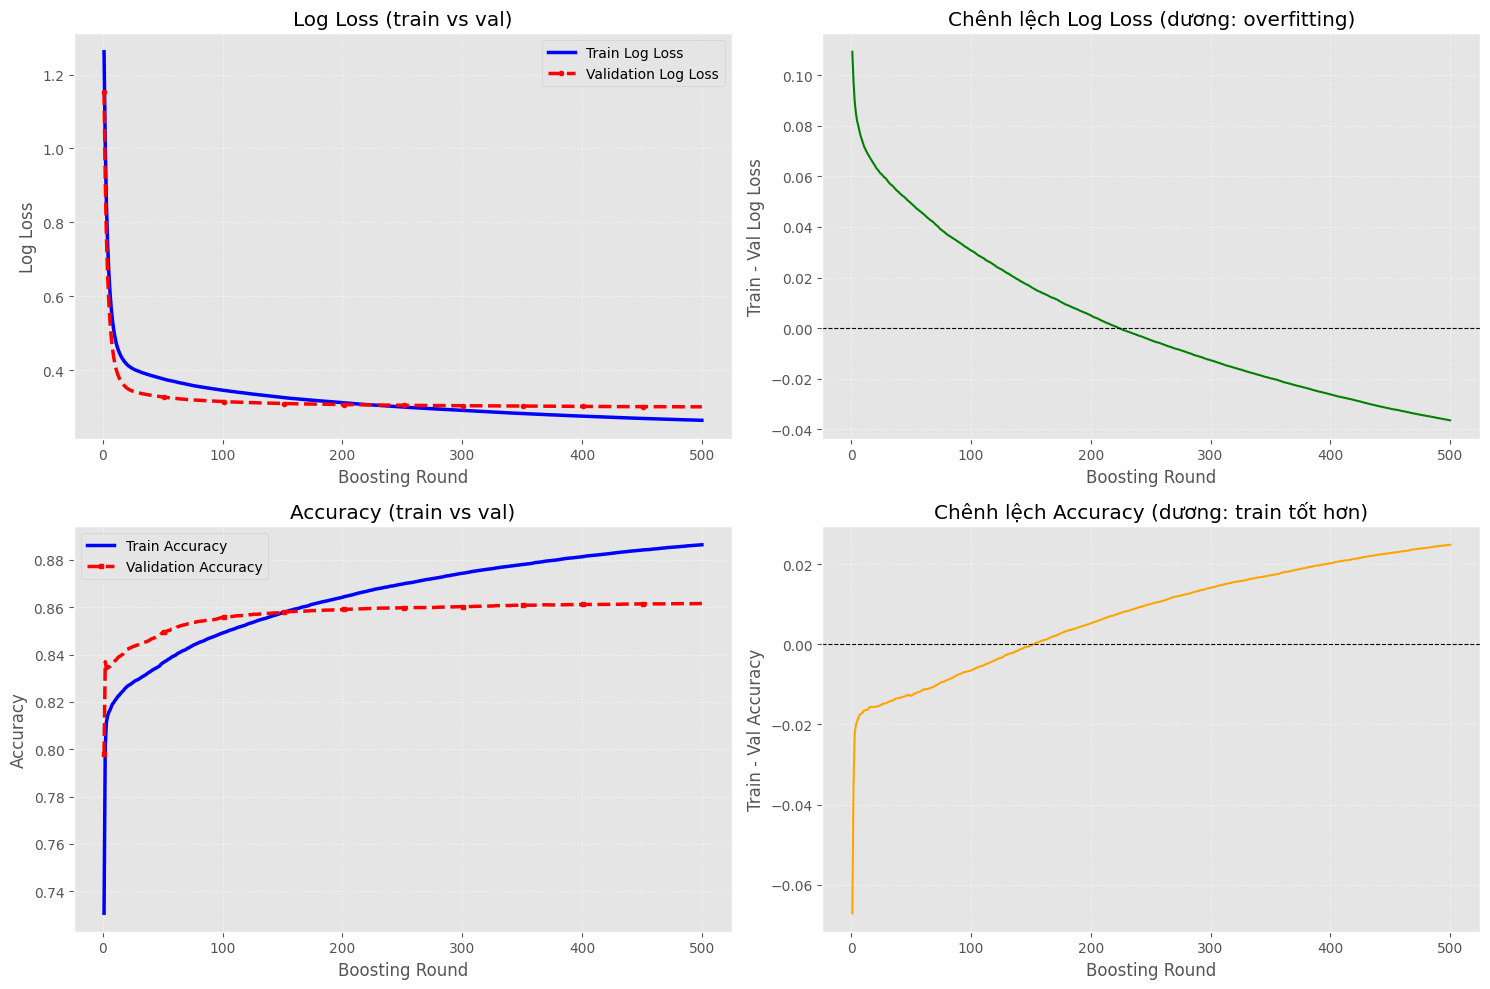

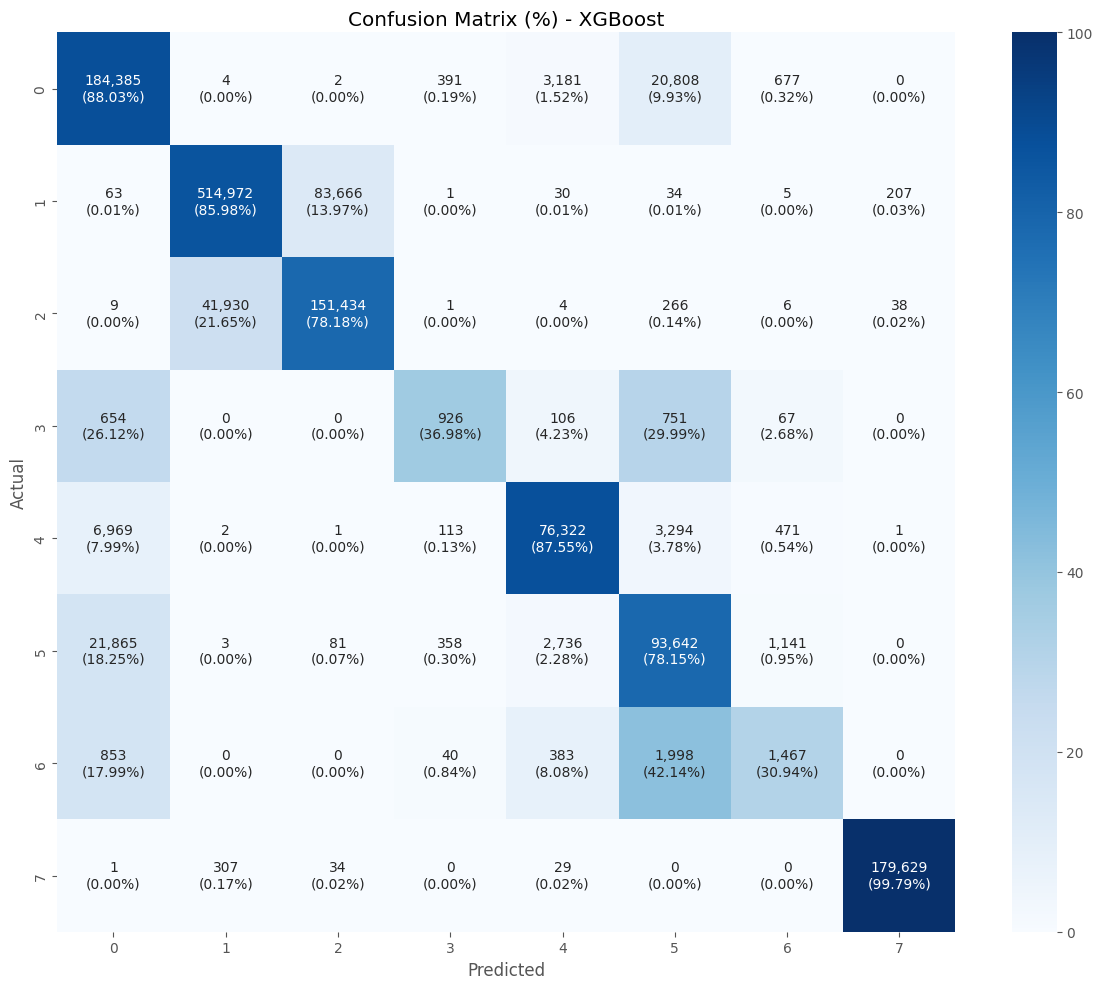

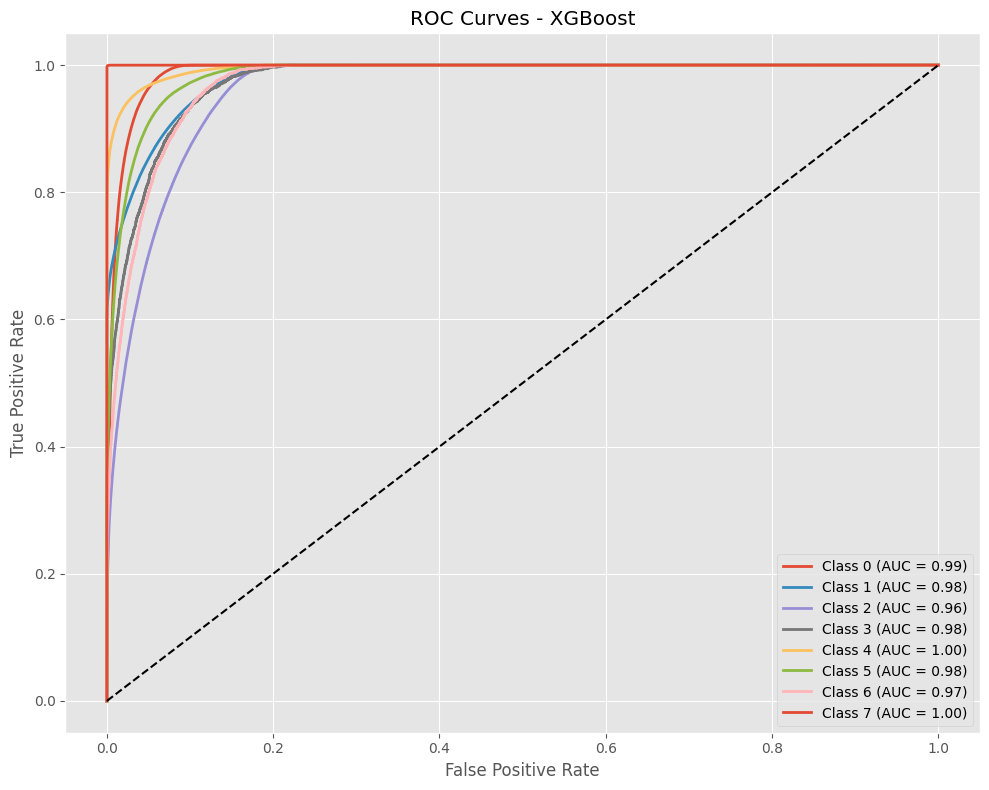

Done. All plots saved.


In [7]:
import json, pandas as pd, numpy as np, xgboost as xgb, matplotlib.pyplot as plt, seaborn as sns, time, os
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix,
                             classification_report, roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize

OUTPUT_DIR = "/kaggle/working/"
with open(f"{OUTPUT_DIR}/metadata.json") as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
target_col = metadata['target_col']
label_to_id = metadata['label_to_id']
num_classes = metadata['num_classes']

model = xgb.XGBClassifier()
model.load_model(f"{OUTPUT_DIR}/xgboost_best_model.json")

TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
df_test = pd.read_parquet(TEST_PATH)
X_test = df_test[feature_cols].values.astype(np.float32)
y_test = df_test[target_col].astype(str).map(label_to_id).values

# Dự đoán
start = time.time()
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
eval_time = time.time() - start

# Metrics
accuracy = accuracy_score(y_test, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_macro = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')

print("=== XGBoost Test Results ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f}")
print(f"AUC (macro): {auc_macro:.4f} | Eval time: {eval_time:.2f}s")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Lưu metrics
with open(f"{OUTPUT_DIR}/xgboost_metrics.json", 'w') as f:
    json.dump({'accuracy': accuracy, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted, 'auc': auc_macro}, f)

# ========== Vẽ biểu đồ ==========
history = json.load(open(f"{OUTPUT_DIR}/xgboost_history.json"))

# Kiểm tra và chuyển đổi dữ liệu an toàn
train_logloss = np.array(history['train']['mlogloss']).flatten()
val_logloss   = np.array(history['validation_0']['mlogloss']).flatten()
train_accuracy = 1 - np.array(history['train']['merror']).flatten()
val_accuracy   = 1 - np.array(history['validation_0']['merror']).flatten()

epochs = np.arange(1, len(train_logloss) + 1)

# Tạo figure với 2 dòng: (Loss + Diff) và (Accuracy + Diff)
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# ----- Loss và chênh lệch Loss -----
ax = axs[0,0]
ax.plot(epochs, train_logloss, 'b-', linewidth=2.5, label='Train Log Loss')
ax.plot(epochs, val_logloss, 'r--', linewidth=2.5, marker='o', markersize=3, markevery=50, label='Validation Log Loss')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('Log Loss (train vs val)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

ax_diff = axs[0,1]
diff_loss = train_logloss - val_logloss
ax_diff.plot(epochs, diff_loss, 'g-', linewidth=1.5)
ax_diff.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
ax_diff.set_xlabel('Boosting Round')
ax_diff.set_ylabel('Train - Val Log Loss')
ax_diff.set_title('Chênh lệch Log Loss (dương: overfitting)')
ax_diff.grid(True, linestyle=':', alpha=0.7)

# ----- Accuracy và chênh lệch Accuracy -----
ax = axs[1,0]
ax.plot(epochs, train_accuracy, 'b-', linewidth=2.5, label='Train Accuracy')
ax.plot(epochs, val_accuracy, 'r--', linewidth=2.5, marker='s', markersize=3, markevery=50, label='Validation Accuracy')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy (train vs val)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

ax_diff_acc = axs[1,1]
diff_acc = train_accuracy - val_accuracy
ax_diff_acc.plot(epochs, diff_acc, 'orange', linewidth=1.5)
ax_diff_acc.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
ax_diff_acc.set_xlabel('Boosting Round')
ax_diff_acc.set_ylabel('Train - Val Accuracy')
ax_diff_acc.set_title('Chênh lệch Accuracy (dương: train tốt hơn)')
ax_diff_acc.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgboost_loss_acc_curves.png", dpi=200)
plt.show()

# Ma trận nhầm lẫn với % và màu theo hàng
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Tạo mảng annot với 2 chữ số thập phân
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i,j]:,}\n({cm_percent[i,j]:.2f}%)"

plt.figure(figsize=(12,10))
sns.heatmap(cm_percent, annot=annot, fmt='', cmap='Blues',
            xticklabels=range(num_classes), yticklabels=range(num_classes),
            vmin=0, vmax=100)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix (%) - XGBoost')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgboost_confusion_percent.png", dpi=150)
plt.show()

# ROC curves
plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc_score(y_test_bin[:, i], y_proba[:, i]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgboost_roc_curves.png", dpi=150)
plt.show()

print("Done. All plots saved.")